In [1]:
import os 


In [17]:
base_dir = '/home/viny/run1'
frames_dir = [os.path.join(base_dir, x) for x in sorted(os.listdir(base_dir)) 
                  if os.path.isdir(os.path.join(base_dir, x))]

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [20]:
frames = []
for frame_dir in frames_dir:
    image_path = os.path.join(frame_dir, 'rgb_image.png')
    if not os.path.exists(image_path): 
        continue
    image = cv2.imread(image_path)
    if image is None:
        continue
    frames.append(image)
frames = np.array(frames)

In [21]:
frames.shape

(1786, 480, 640, 3)

In [23]:
sift = cv2.SIFT_create()
# Variables for feature tracking
prev_frame = None
prev_keypoints = None
prev_descriptors = None
transforms = np.zeros((len(frames), 3))  # Tracks the cumulative motion
n_frames, h, w, c = frames.shape

# Iterate over frames
for i, frame in tqdm(enumerate(frames), total=n_frames, desc="Processing frames"):
    # Convert frame to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev_frame is not None:
        # Detect keypoints and compute descriptors for current frame
        keypoints, descriptors = sift.detectAndCompute(gray, None)

        if prev_keypoints is not None and descriptors is not None:
            # Create a BFMatcher object
            matcher = cv2.BFMatcher()
            matches = matcher.knnMatch(prev_descriptors, descriptors, k=2)

            # Apply ratio test to filter good matches
            good_matches = []
            for m, n in matches:
                if m.distance < 0.75 * n.distance:
                    good_matches.append(m)

            if len(good_matches) > 10:
                src_pts = np.float32([prev_keypoints[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
                dst_pts = np.float32([keypoints[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

                # Calculate the homography matrix using RANSAC
                M, inliers = cv2.estimateAffine2D(src_pts, dst_pts, method=cv2.RANSAC)

                if M is not None:
                    dx = M[0, 2]
                    dy = M[1, 2]
                    # Extract rotation angle
                    da = np.arctan2(M[1, 0], M[0, 0])
                    # Store transformation
                    transforms[i] = [dx, dy, da]

        # Update the previous keypoints and descriptors
        prev_keypoints = keypoints
        prev_descriptors = descriptors

    # Update the previous frame
    prev_frame = gray

trajectory = np.cumsum(transforms, axis=0)

Processing frames: 100%|██████████| 1786/1786 [00:29<00:00, 61.05it/s]


In [24]:
trajectory.shape

(1786, 3)

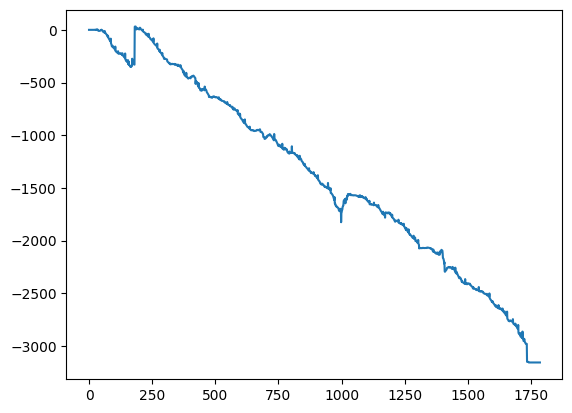

In [25]:
plt.plot(trajectory[:,1])